In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
!git clone https://github.com/ai-agriculture-circuits-and-systems/Plant_Village_Tomato.git

Cloning into 'Plant_Village_Tomato'...
remote: Enumerating objects: 200785, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 200785 (delta 0), reused 1 (delta 0), pack-reused 200782 (from 1)
Receiving objects: 100% (200785/200785), 721.78 MiB | 19.28 MiB/s, done.
Resolving deltas: 100% (52828/52828), done.
Updating files: 100% (242339/242339), done.


In [3]:
tomato_root = "/content/Plant_Village_Tomato/tomatoes"

class_names = sorted([
    folder for folder in os.listdir(tomato_root)
    if os.path.isdir(os.path.join(tomato_root, folder))
])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['bacterial_spot', 'early_blight', 'healthy', 'late_blight', 'leaf_mold', 'septoria_leaf_spot', 'spider_mites_two_spotted_spider_mite', 'target_spot', 'tomato_mosaic_virus', 'tomato_yellow_leaf_curl_virus']
Number of classes: 10


In [4]:
for class_name in class_names:
    image_path = os.path.join(
        tomato_root, class_name, "color", "images"
    )

    count = len([
        f for f in os.listdir(image_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(class_name, ":", count)

bacterial_spot : 2127
early_blight : 1000
healthy : 1591
late_blight : 1909
leaf_mold : 952
septoria_leaf_spot : 1771
spider_mites_two_spotted_spider_mite : 1676
target_spot : 1404
tomato_mosaic_virus : 373
tomato_yellow_leaf_curl_virus : 5357


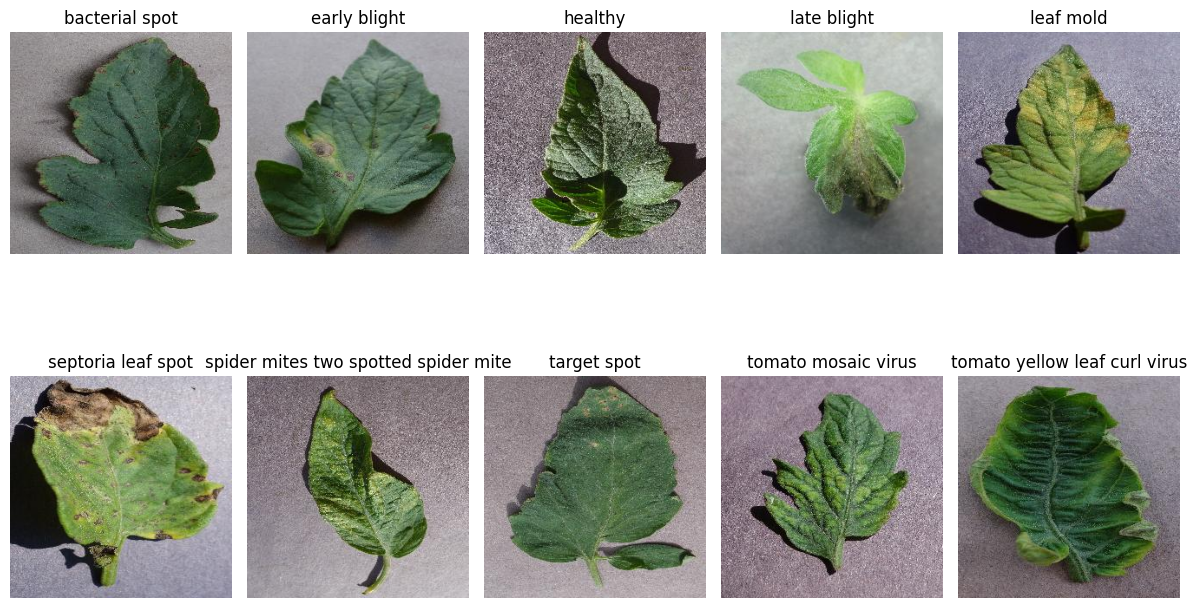

In [5]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    image_path = os.path.join(
        tomato_root, class_name, "color", "images"
    )

    image_file = next(
        f for f in os.listdir(image_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    image = plt.imread(os.path.join(image_path, image_file))

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("_", " "))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Create a reduced dataset containing 500 images from each class
reduced_dataset = "/content/tomato_dataset"

os.makedirs(reduced_dataset, exist_ok=True)

for class_name in class_names:
    source = os.path.join(
        tomato_root, class_name, "color", "images"
    )

    destination = os.path.join(
        reduced_dataset, class_name
    )

    os.makedirs(destination, exist_ok=True)

    image_files = [
        f for f in os.listdir(source)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select up to 500 images from each class
    selected_files = image_files[:500]

    for file in selected_files:
        source_file = os.path.join(source, file)
        destination_file = os.path.join(destination, file)

        if not os.path.exists(destination_file):
            shutil.copy2(source_file, destination_file)

print("Reduced dataset created successfully.")

Reduced dataset created successfully.


In [13]:
# Count images available in each class
for class_name in class_names:
    class_path = os.path.join(reduced_dataset, class_name)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(class_name, ":", count)

bacterial_spot : 2127
early_blight : 1000
healthy : 1591
late_blight : 1909
leaf_mold : 952
septoria_leaf_spot : 1771
spider_mites_two_spotted_spider_mite : 1676
target_spot : 1404
tomato_mosaic_virus : 373
tomato_yellow_leaf_curl_virus : 5357


In [14]:
# Define image dimensions and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load 80% of the images for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    reduced_dataset,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Load 20% of the images for validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    reduced_dataset,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 18160 files belonging to 10 classes.
Using 14528 files for training.
Found 18160 files belonging to 10 classes.
Using 3632 files for validation.


In [15]:
# Scale pixel values from the range 0-255 to the range 0-1
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [16]:
# Define the CNN architecture
model = models.Sequential([

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a one-dimensional vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer for 10 classes
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Configure the optimizer, loss function and evaluation metric
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train the CNN model using the training and validation datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.6189 - loss: 1.1292 - val_accuracy: 0.7819 - val_loss: 0.6749
Epoch 2/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.7826 - loss: 0.6489 - val_accuracy: 0.8610 - val_loss: 0.4144
Epoch 3/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.8329 - loss: 0.4863 - val_accuracy: 0.8956 - val_loss: 0.3097
Epoch 4/5
454/454 ━━━━━━━━━━━━━━━━━━━━ 483s 1s/step - accuracy: 0.8524 - loss: 0.4179 - val_accuracy: 0.9097 - val_loss: 0.2814
Epoch 5/5
424/454 ━━━━━━━━━━━━━━━━━━━━ 29s 986ms/step - accuracy: 0.8717 - loss: 0.3623

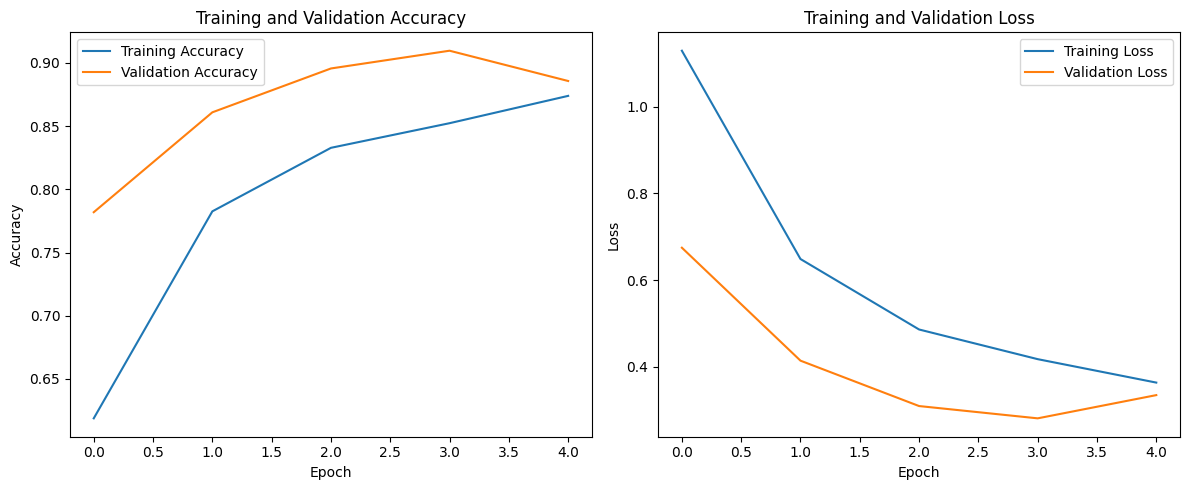

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Evaluate the trained model on validation data
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

114/114 ━━━━━━━━━━━━━━━━━━━━ 40s 350ms/step - accuracy: 0.8857 - loss: 0.3350
Validation Loss: 0.33496996760368347
Validation Accuracy: 0.8857378959655762


In [21]:
# Store actual and predicted class labels
y_true = []
y_pred = []

for images, labels in val_ds:
    # Generate predictions for the validation images
    predictions = model.predict(images, verbose=0)

    # Convert one-hot encoded labels to class indices
    y_true.extend(np.argmax(labels.numpy(), axis=1))

    # Select the class with the highest prediction probability
    y_pred.extend(np.argmax(predictions, axis=1))

# Calculate precision, recall and F1-score
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                      precision    recall  f1-score   support

                      bacterial_spot       0.86      0.97      0.91       428
                        early_blight       0.68      0.66      0.67       181
                             healthy       0.99      0.89      0.94       298
                         late_blight       0.88      0.88      0.88       397
                           leaf_mold       0.96      0.68      0.80       208
                  septoria_leaf_spot       0.91      0.77      0.83       354
spider_mites_two_spotted_spider_mite       0.79      0.91      0.85       327
                         target_spot       0.79      0.83      0.81       289
                 tomato_mosaic_virus       0.89      0.84      0.86        67
       tomato_yellow_leaf_curl_virus       0.95      0.98      0.96      1083

                            accuracy                           0.89      3632
                           macro avg       0.87      0.84     

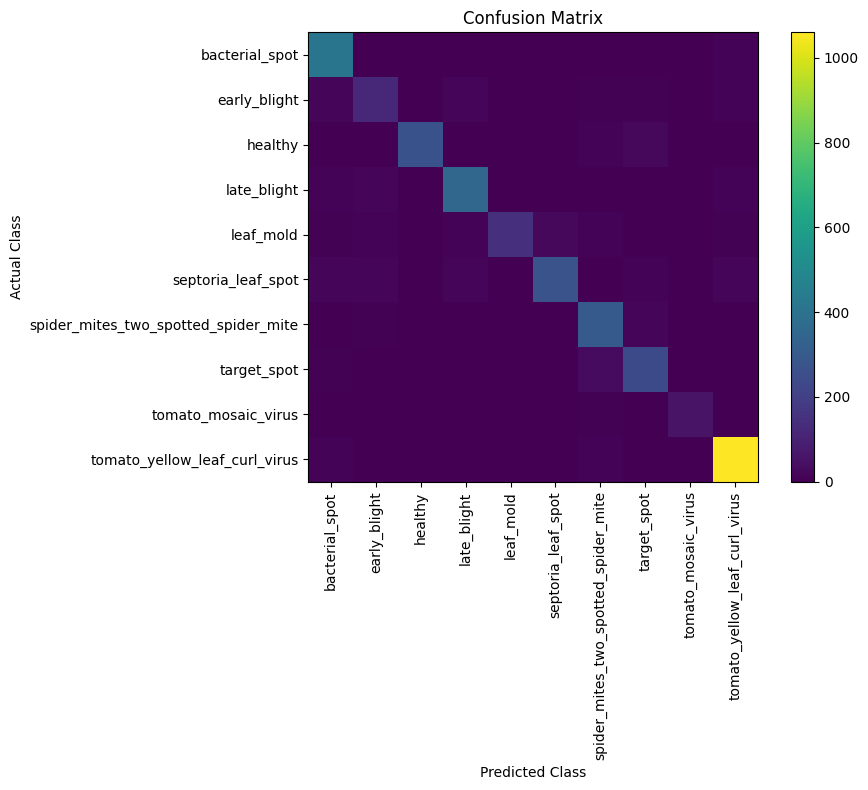

In [22]:
# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [23]:
# Upload a new tomato leaf image for disease prediction
from google.colab import files

uploaded = files.upload()

Saving tomato leaf.jpeg to tomato leaf.jpeg


In [24]:
# Get the uploaded image file name
image_path = next(iter(uploaded))

# Load and resize the image to the model input size
image = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

# Convert the image to an array
image_array = tf.keras.utils.img_to_array(image)

# Normalize pixel values to the range 0-1
image_array = image_array / 255.0

# Add batch dimension for model prediction
image_array = np.expand_dims(image_array, axis=0)

# Generate class probabilities
predictions = model.predict(image_array)

# Select the class with the highest probability
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]

# Calculate prediction confidence
confidence = predictions[0][predicted_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Disease: spider_mites_two_spotted_spider_mite
Confidence: 56.10%
